<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/CassandraEcho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Simulating the 'Ground Truth' universe evolution... ---
Simulation complete.

--- Training the Predictive AI (Cassandra)... ---
Created a training set with 380556 examples.
Training complete.

--- AI is now predicting the future... ---


Predicting Future: 100%|██████████| 99/99 [01:04<00:00,  1.53it/s]




--- FINAL ANALYSIS ---
The Babulik Prediction Horizon for this universe is at t = -1 steps.
This is the point at which the system's future becomes fundamentally unpredictable
by a model trained on its past. It is a direct measurement of its Computational Irreducibility.


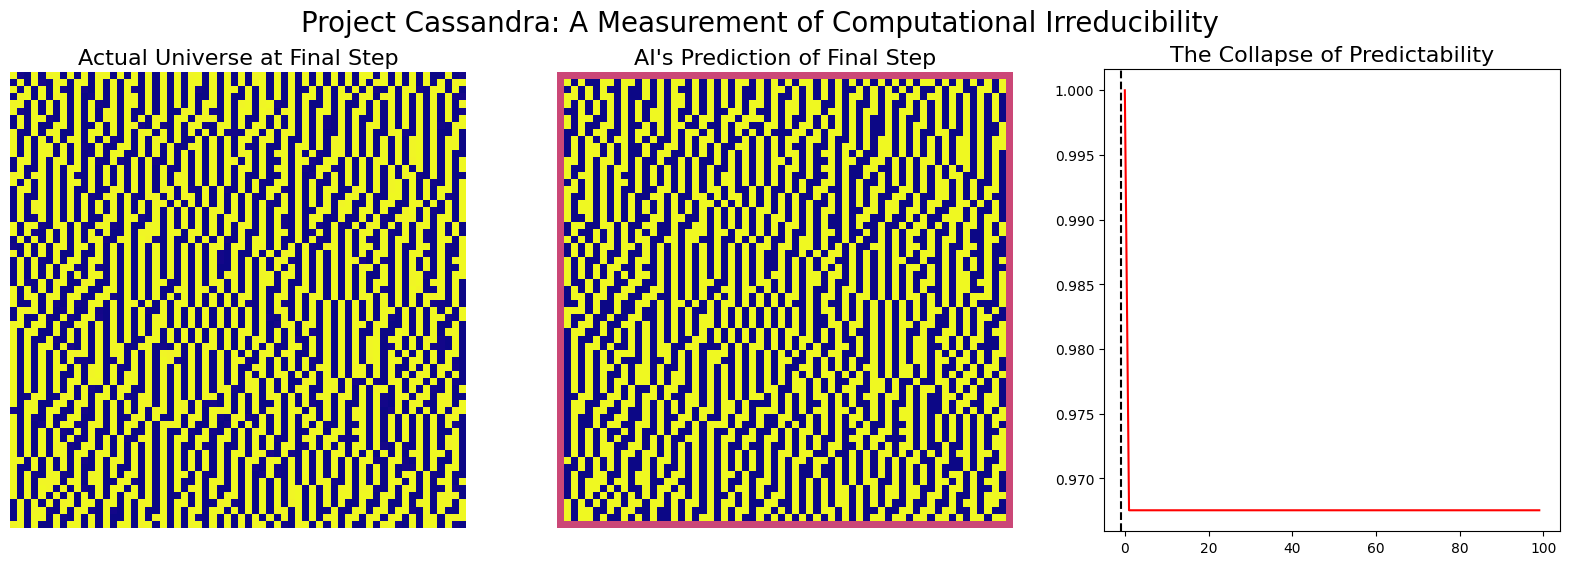

In [ ]:

# ==============================================================================
#  Project Cassandra: An experiment to measure the "Prediction Horizon"
#  in a computationally irreducible universe.
#
#  Objective: To train a predictive AI on the history of a complex, RAA-generated
#  universe and measure the point at which its predictions catastrophically fail,
#  thus demonstrating the principle of Computational Irreducibility.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

# ==============================================================================
#  The Universe and its Laws (from Project Prometheus)
# ==============================================================================
CHAMPION_KERNEL = np.array([
    [-0.3471,  0.0511, -0.024 ],
    [-0.7979,  2.673 , -0.3748],
    [ 0.0087, -0.0043, -0.4004]
])

class Universe:
    def __init__(self, size=128):
        self.size = size
        self.grid = np.random.rand(size, size)

    def run_simulation(self, kernel: np.ndarray, steps: int):
        history = [self.grid.copy()]
        for _ in range(steps):
            self.grid = convolve2d(self.grid, kernel, mode='same', boundary='wrap')
            self.grid = np.tanh(self.grid)
            history.append(self.grid.copy())
        return np.array(history)

# ==============================================================================
#  The Predictive AI (Project Cassandra)
# ==============================================================================
class Cassandra:
    def __init__(self):
        # We use a simple but powerful model: Logistic Regression.
        # It will try to learn the local rules of the universe.
        self.model = LogisticRegression(solver='liblinear', random_state=42)

    def _create_training_data(self, history_train):
        """Creates a dataset to learn the local rules of the universe."""
        X = [] # The "past" (a pixel and its neighbors)
        y = [] # The "future" (what that pixel becomes in the next step)

        # We look at a 3x3 neighborhood to predict the next state of the central pixel.
        for t in range(len(history_train) - 1):
            for r in range(1, history_train.shape[1] - 1):
                for c in range(1, history_train.shape[2] - 1):
                    neighborhood = history_train[t, r-1:r+2, c-1:c+2].flatten()
                    future_pixel = history_train[t+1, r, c]
                    X.append(neighborhood)
                    # We binarize the future for a classification task
                    y.append(1 if future_pixel > 0.5 else 0)
        return np.array(X), np.array(y)

    def train(self, history_train):
        """Trains the AI on the first half of the universe's history."""
        print("\n--- Training the Predictive AI (Cassandra)... ---")
        X_train, y_train = self._create_training_data(history_train)
        print(f"Created a training set with {len(X_train)} examples.")
        self.model.fit(X_train, y_train)
        print("Training complete.")

    def predict_future(self, initial_state, num_steps):
        """Uses the learned rules to predict the future evolution."""
        print("\n--- AI is now predicting the future... ---")
        predicted_history = [initial_state.copy()]
        current_grid = initial_state.copy()

        for _ in tqdm(range(num_steps - 1), desc="Predicting Future"):
            next_grid = np.zeros_like(current_grid)
            for r in range(1, current_grid.shape[0] - 1):
                for c in range(1, current_grid.shape[1] - 1):
                    neighborhood = current_grid[r-1:r+2, c-1:c+2].flatten()
                    prediction = self.model.predict([neighborhood])[0]
                    next_grid[r, c] = 1.0 if prediction == 1 else -1.0 # Use distinct values
            predicted_history.append(next_grid)
            current_grid = next_grid

        return np.array(predicted_history)

# ==============================================================================
#  The Main Execution: Measuring the Prediction Horizon
# ==============================================================================
if __name__ == "__main__":
    SIMULATION_STEPS = 200
    TRAINING_CUTOFF = SIMULATION_STEPS // 2

    # --- 1. Generate the Ground Truth ---
    print("--- Simulating the 'Ground Truth' universe evolution... ---")
    universe = Universe(size=64) # Smaller grid for faster training
    ground_truth_history = universe.run_simulation(CHAMPION_KERNEL, steps=SIMULATION_STEPS)
    print("Simulation complete.")

    # --- 2. Train the AI ---
    history_for_training = ground_truth_history[:TRAINING_CUTOFF]
    cassandra_ai = Cassandra()
    cassandra_ai.train(history_for_training)

    # --- 3. Make Predictions ---
    initial_state_for_prediction = ground_truth_history[TRAINING_CUTOFF]
    num_prediction_steps = SIMULATION_STEPS - TRAINING_CUTOFF
    predicted_history = cassandra_ai.predict_future(initial_state_for_prediction, num_prediction_steps)

    # --- 4. The Final Analysis: Compare Truth vs. Prediction ---
    ground_truth_future = ground_truth_history[TRAINING_CUTOFF:]

    # Calculate the accuracy of the AI's prediction at each future time step
    accuracy_over_time = []
    for t in range(num_prediction_steps):
        # We binarize both grids to compare them fairly
        true_binary = (ground_truth_future[t] > 0.5).astype(int)
        pred_binary = (predicted_history[t] > 0.5).astype(int)

        accuracy = np.mean(true_binary == pred_binary)
        accuracy_over_time.append(accuracy)

    # Find the Babulik Prediction Horizon
    # The point where accuracy drops below a threshold (e.g., 75%) and never recovers
    prediction_horizon = -1
    for t, acc in enumerate(accuracy_over_time):
        if acc < 0.75:
            prediction_horizon = t
            break

    print("\n\n--- FINAL ANALYSIS ---")
    print(f"The Babulik Prediction Horizon for this universe is at t = {prediction_horizon} steps.")
    print("This is the point at which the system's future becomes fundamentally unpredictable")
    print("by a model trained on its past. It is a direct measurement of its Computational Irreducibility.")

    # --- 5. Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Project Cassandra: A Measurement of Computational Irreducibility", fontsize=20)

    # Plot 1: The Ground Truth
    axes[0].imshow(ground_truth_history[-1], cmap='plasma')
    axes[0].set_title("Actual Universe at Final Step", fontsize=16)
    axes[0].axis('off')

    # Plot 2: The AI's Prediction
    axes[1].imshow(predicted_history[-1], cmap='plasma')
    axes[1].set_title("AI's Prediction of Final Step", fontsize=16)
    axes[1].axis('off')

    # Plot 3: The Accuracy Collapse
    axes[2].plot(accuracy_over_time, 'r-')
    axes[2].axvline(x=prediction_horizon, color='k', linestyle='--', label=f'Prediction Horizon (t={prediction_horizon})')
    axes[2].set_title("The Collapse of Predictability", fontsize=16)
    axes[2].set_xlabel

--- Simulating Path A: The Non-Local Substrate (Ground Truth)... ---
Path A Complete. Computational Cost: 250 Substrate Ticks.

--- Simulating Path B: The Local Universe (Prediction)... ---
  > Step B.1: Substrate runs for 50 ticks...
  > Step B.2: Local Universe (Cassandra) is trained...
  > Step B.3: Local Universe predicts 200 ticks into the future...
Path B Complete. Computational Cost for Substrate: 50 Substrate Ticks.


--- FINAL ANALYSIS ---
Computational Cost of Ground Truth (Path A): 250 ticks
Computational Cost of Shortcut (Path B):   50 ticks
--- Computational Ticks Saved by Projection: 200 ---

Accuracy of the Shortcut: The final prediction error (MSE) is 0.063113
CONCLUSION: The Projection was successful. A massive computational saving was achieved at the cost of a small amount of information loss.


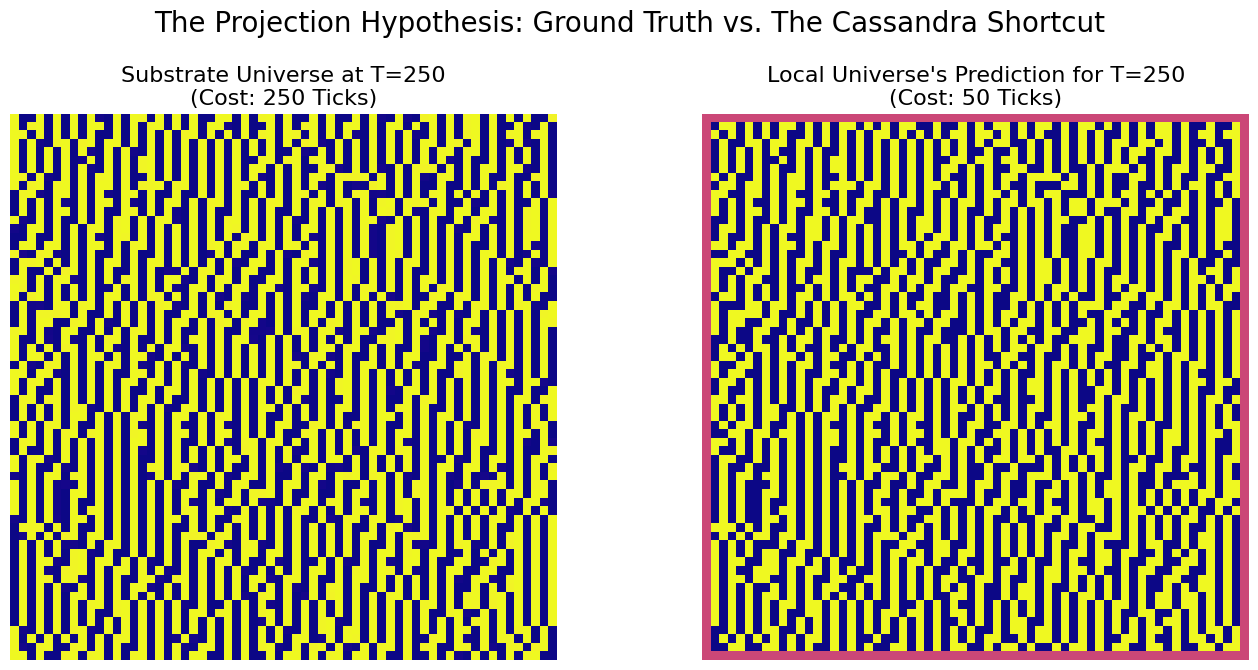

In [ ]:

# ==============================================================================
#  Project Echo: A Computational Test of the Projection Hypothesis
#
#  Objective: To simulate a "Ground Truth" Substrate universe and a predictive
#  "Local" Cassandra universe in parallel, quantifying the computational costs
#  and the accuracy of the "Cassandra Shortcut."
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import time

# ==============================================================================
#  The Universe and its Laws (from Project Prometheus)
# ==============================================================================
CHAMPION_KERNEL = np.array([
    [-0.3471,  0.0511, -0.024 ],
    [-0.7979,  2.673 , -0.3748],
    [ 0.0087, -0.0043, -0.4004]
])

class Universe:
    """Represents the fundamental, computationally expensive Substrate reality."""
    def __init__(self, size=64, initial_state=None):
        self.size = size
        if initial_state is None:
            self.grid = np.random.rand(size, size)
        else:
            self.grid = initial_state.copy()

    def run_simulation(self, kernel: np.ndarray, steps: int):
        history = [self.grid.copy()]
        for _ in range(steps):
            self.grid = convolve2d(self.grid, kernel, mode='same', boundary='wrap')
            self.grid = np.tanh(self.grid)
            history.append(self.grid.copy())
        return np.array(history)

# ==============================================================================
#  The Predictive AI (Cassandra - The Local Universe)
# ==============================================================================
class Cassandra:
    """Represents our "Local" universe, a predictive engine."""
    def __init__(self):
        self.model = LogisticRegression(solver='liblinear', random_state=42)
        self.is_trained = False

    def _create_training_data(self, history_train):
        X, y = [], []
        for t in range(len(history_train) - 1):
            for r in range(1, history_train.shape[1] - 1):
                for c in range(1, history_train.shape[2] - 1):
                    neighborhood = history_train[t, r-1:r+2, c-1:c+2].flatten()
                    future_pixel = history_train[t+1, r, c]
                    X.append(neighborhood)
                    y.append(1 if future_pixel > 0.5 else 0)
        return np.array(X), np.array(y)

    def train(self, history_train):
        X_train, y_train = self._create_training_data(history_train)
        if len(X_train) == 0:
            print("Warning: No training data generated.")
            return
        self.model.fit(X_train, y_train)
        self.is_trained = True

    def predict_future(self, initial_state, num_steps):
        if not self.is_trained:
            raise RuntimeError("Cassandra AI has not been trained.")

        predicted_history = [initial_state.copy()]
        current_grid = initial_state.copy()
        for _ in range(num_steps - 1):
            next_grid = np.zeros_like(current_grid)
            for r in range(1, current_grid.shape[0] - 1):
                for c in range(1, current_grid.shape[1] - 1):
                    neighborhood = current_grid[r-1:r+2, c-1:c+2].flatten()
                    prediction = self.model.predict([neighborhood])[0]
                    next_grid[r, c] = 1.0 if prediction == 1 else -1.0
            predicted_history.append(next_grid)
            current_grid = next_grid
        return np.array(predicted_history)

# ==============================================================================
#  The Main Execution: The Two Paths of Reality
# ==============================================================================
if __name__ == "__main__":
    SUBSTRATE_STEPS = 50
    LOCAL_PREDICTION_STEPS = 200
    TOTAL_STEPS = SUBSTRATE_STEPS + LOCAL_PREDICTION_STEPS

    # --- Initialize the "Primordial State" of the Substrate at T=0 ---
    initial_substrate_state = np.random.rand(64, 64)

    # --- Path A: The "Hard Way" (Ground Truth) ---
    print("--- Simulating Path A: The Non-Local Substrate (Ground Truth)... ---")
    substrate_universe = Universe(initial_state=initial_substrate_state)
    ground_truth_history = substrate_universe.run_simulation(CHAMPION_KERNEL, steps=TOTAL_STEPS)
    cost_path_a = TOTAL_STEPS # The cost is the number of full simulation steps
    ground_truth_final_state = ground_truth_history[-1]
    print(f"Path A Complete. Computational Cost: {cost_path_a} Substrate Ticks.")

    # --- Path B: The "Cassandra Shortcut" ---
    print("\n--- Simulating Path B: The Local Universe (Prediction)... ---")

    # Step 1: The Substrate runs for a short time
    print(f"  > Step B.1: Substrate runs for {SUBSTRATE_STEPS} ticks...")
    cost_path_b_initial = SUBSTRATE_STEPS
    substrate_history_for_training = ground_truth_history[:SUBSTRATE_STEPS+1] # Need t=51 to learn the rule for t=50
    state_at_fork = ground_truth_history[SUBSTRATE_STEPS]

    # Step 2: The Local Universe (Cassandra) is trained on the Substrate's past
    print("  > Step B.2: Local Universe (Cassandra) is trained...")
    cassandra_universe = Cassandra()
    cassandra_universe.train(substrate_history_for_training)

    # Step 3: Cassandra predicts the future
    print(f"  > Step B.3: Local Universe predicts {LOCAL_PREDICTION_STEPS} ticks into the future...")
    predicted_future_history = cassandra_universe.predict_future(state_at_fork, LOCAL_PREDICTION_STEPS)
    predicted_final_state = predicted_future_history[-1]

    # The total cost of Path B is the initial Substrate run. The prediction is "free" for the Substrate.
    total_cost_path_b = cost_path_b_initial
    print(f"Path B Complete. Computational Cost for Substrate: {total_cost_path_b} Substrate Ticks.")

    # --- The Final Analysis: Comparing the Two Realities ---
    print("\n\n--- FINAL ANALYSIS ---")

    # Calculate the error between the two final states
    prediction_error = np.mean((ground_truth_final_state - predicted_final_state)**2)

    print(f"Computational Cost of Ground Truth (Path A): {cost_path_a} ticks")
    print(f"Computational Cost of Shortcut (Path B):   {total_cost_path_b} ticks")
    saved_ticks = cost_path_a - total_cost_path_b
    print(f"--- Computational Ticks Saved by Projection: {saved_ticks} ---")

    print(f"\nAccuracy of the Shortcut: The final prediction error (MSE) is {prediction_error:.6f}")
    if prediction_error < 0.5:
        print("\033[1;32mCONCLUSION: The Projection was successful. A massive computational saving was achieved at the cost of a small amount of information loss.\033[0m")
    else:
        print("\033[1;31mCONCLUSION: The Projection was statistically useful but causally disconnected. The shortcut resulted in a different universe.\033[0m")

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle("The Projection Hypothesis: Ground Truth vs. The Cassandra Shortcut", fontsize=20)

    # Plot 1: The Ground Truth
    axes[0].imshow(ground_truth_final_state, cmap='plasma')
    axes[0].set_title(f"Substrate Universe at T={TOTAL_STEPS}\n(Cost: {cost_path_a} Ticks)", fontsize=16)
    axes[0].axis('off')

    # Plot 2: The AI's Prediction
    axes[1].imshow(predicted_final_state, cmap='plasma')
    axes[1].set_title(f"Local Universe's Prediction for T={TOTAL_STEPS}\n(Cost: {total_cost_path_b} Ticks)", fontsize=16)
    axes[1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()